# INF250 - Assignment 3

In [12]:
from ultralytics import YOLO
import os
import torch
from torchvision.transforms import v2
from PIL import Image
import matplotlib.pyplot as plt

In [5]:
# Augmentations for images
transforms = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [8]:
model = YOLO("yolov8s.pt")

# Dataset folder
dataset_folder = "Rumex/"

# Train the model
model.train(data=os.path.join(dataset_folder, "data.yaml"), epochs=50, imgsz=640, batch=8)

Ultralytics 8.3.228 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7850MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Rumex/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d21f401b970>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [11]:
best = YOLO(os.path.join(model.trainer.save_dir, "weights/best.pt"))
test_images = os.path.join(dataset_folder, "test/images")

results = best.predict(source=test_images, save=True)

metrics = best.val(data=os.path.join(dataset_folder, "data.yaml"))
print(metrics)


image 1/11 /home/frederic/Documents/INF250/assignment_3/Rumex/test/images/DJI_20250906164728_0027_D_part2_jpg.rf.8e78cb33e014c5bb4e9cb061897000b3.jpg: 640x640 6 rumexs, 5.5ms
image 2/11 /home/frederic/Documents/INF250/assignment_3/Rumex/test/images/DJI_20250906165011_0121_D_part2_jpg.rf.726a23544af9496d02f2c245b0872413.jpg: 640x640 27 rumexs, 5.5ms
image 3/11 /home/frederic/Documents/INF250/assignment_3/Rumex/test/images/DJI_20250906165231_0202_D_part3_jpg.rf.2e574e06c17fe3473e101ab2e14f23d7.jpg: 640x640 18 rumexs, 5.9ms
image 4/11 /home/frederic/Documents/INF250/assignment_3/Rumex/test/images/DJI_20250906165252_0214_D_part2_jpg.rf.28c50573421316c8b8ccf0a99b7a0e4f.jpg: 640x640 20 rumexs, 5.5ms
image 5/11 /home/frederic/Documents/INF250/assignment_3/Rumex/test/images/DJI_20250906165302_0220_D_part2_jpg.rf.7db0913b312fd408172a8d6054cc452b.jpg: 640x640 25 rumexs, 5.5ms
image 6/11 /home/frederic/Documents/INF250/assignment_3/Rumex/test/images/DJI_20250906165302_0220_D_part4_jpg.rf.06bbb67

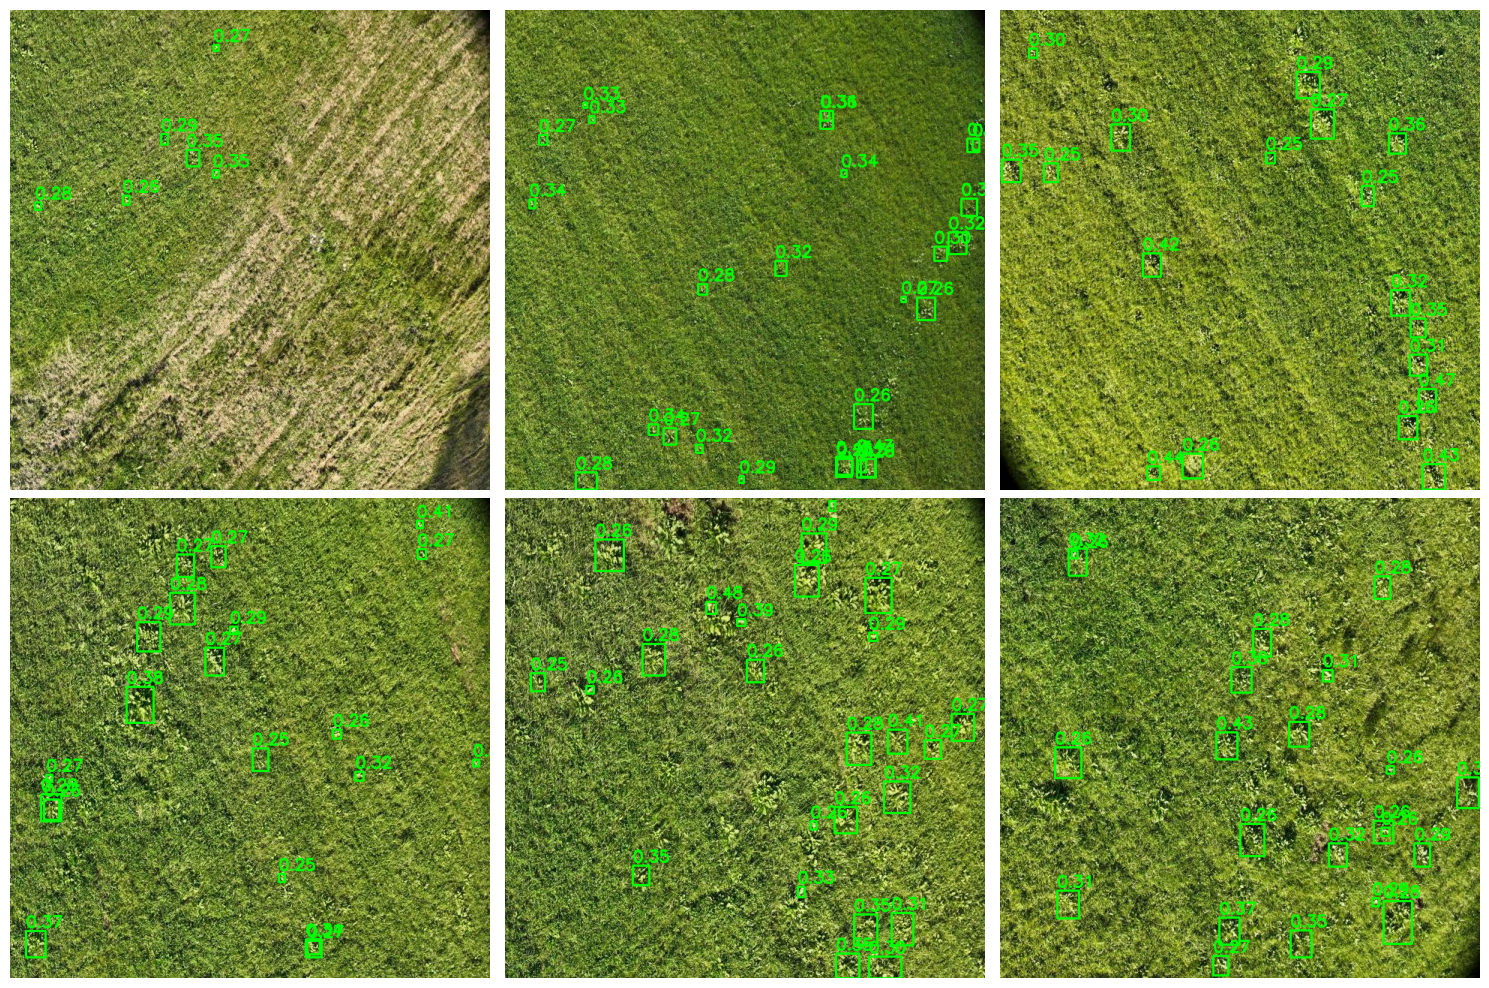

In [ ]:
%matplotlib inline

imgs = []
for r in results:
    x = r.plot()
    imgs.append(x[:, :, ::-1])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.axis("off")
    else:
        ax.remove()

plt.tight_layout()
plt.show()
